### LA Lab2
Least Squares Method
**Yelyzaveta Motorna**

[GitHub](https://github.com/ymotorna/Linear-Algebra/blob/master/least_squares_method.ipynb)

In [10]:
# import libraries
import numpy as np
import numpy.linalg as la
import wooldridge as woo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**Task 1:** Function accepting vector *x* and non-negative int power *p* -> returns polynomial data matrix as *NumPy* array

In [11]:
# func
def compute_data_matrix(x: np.ndarray, p, print_matx=False):
    # verify p = int and >=0
    if type(p) != int:
        print('\033[91m', 'p must be an integer', '\033[91m')
        return None
    elif p <0:
        print('\033[91m', 'p must be greater than 0', '\033[91m')
        return None
    
    # calc matx
    polinom_matx = np.vander(x, p+1)
    
    if print_matx:
        print(f'Output polynomial data matrix:\n{polinom_matx}')
    return polinom_matx


In [12]:
# examples
vector = np.random.randint(10, size=5)

print('Test 1 -----------------------')
p_val_int = np.random.randint(1, 4)
print('Input vector:', vector, '\nInput power (int):', p_val_int)
test_matx_int = compute_data_matrix(vector, p_val_int, print_matx=True)


print('\nTest 2 -----------------------')
p_val_float = np.random.rand(0, 4)
print('Input vector:', vector, '\nInput power (float):', p_val_float)
test_matx_float = compute_data_matrix(vector, p_val_float, print_matx=True)


Test 1 -----------------------
Input vector: [2 7 4 6 0] 
Input power (int): 3
Output polynomial data matrix:
[[  8   4   2   1]
 [343  49   7   1]
 [ 64  16   4   1]
 [216  36   6   1]
 [  0   0   0   1]]

Test 2 -----------------------
Input vector: [2 7 4 6 0] 
Input power (float): []
 p must be an integer 


**Task2:** Load and visualize data; Find *p*

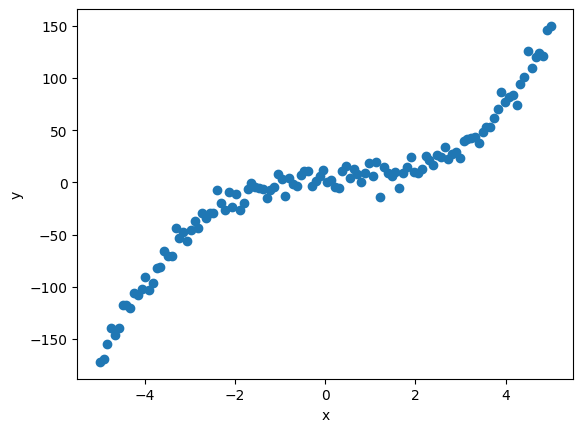

Reasonable power P: 120


In [13]:
# func to visualize data
def visualize_data(x, y):
 assert x.size == y.size
 fig, ax = plt.subplots()
 ax.scatter(x, y)
 ax.set_xlabel('x')
 ax.set_ylabel('y')
 plt.show()
 return

# load data
data = np.load("polynomial_data.npz")
# visualize data
x, y = data['x'], data['y']
visualize_data(x, y)

# reasonable power
power = len(x)
# check #inputs = #outputs
if power == len(y):
    print('Reasonable power P:', power)
else:
    print('\033[91m', 'Number of outputs is not the same as the number of inputs', '\033[91m')
    
    

**Task2:** Compute the least squares solution line; Plot it against the data

In [14]:
# func
def plot_least_squares(x, y, p):
 assert x.size == y.size
 X = compute_data_matrix(x, p) # calc data matx
 c_hat = np.linalg.inv(X.T @ X) @ X.T @ y # calc least-squares solution 
 f = X @ c_hat # calc least-squares output
 
 # plot
 fig, ax = plt.subplots()
 
 ax.scatter(x, y, label='orig data') # original data
 ax.plot(x, f, 'k--', label='LS fit') # least squares fit line
 
 ax.set_xlabel('x')
 ax.set_ylabel('y')
 ax.legend()
 ax.set_title(f"Least Squares Polynomial fit with degree ={p}")
 
 plt.show()
 return


Test 1 -----------------------
Values of p: [1, 2, 3, 5, 15, 75, 120]
power: 1


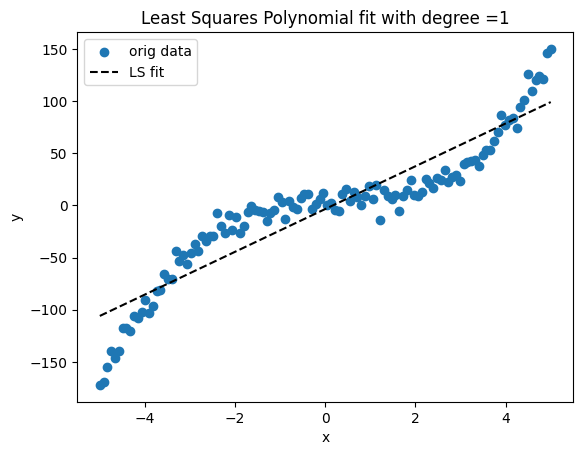

power: 2


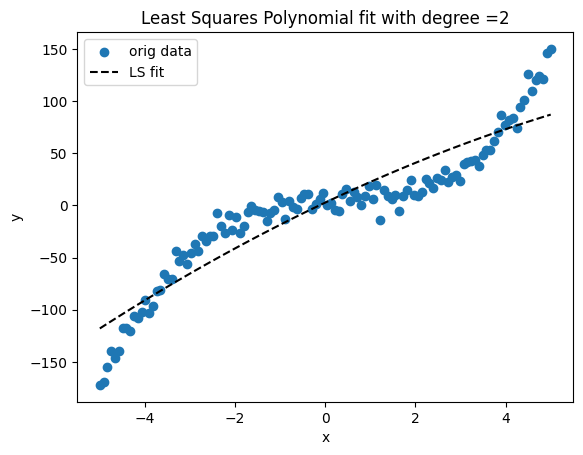

power: 3


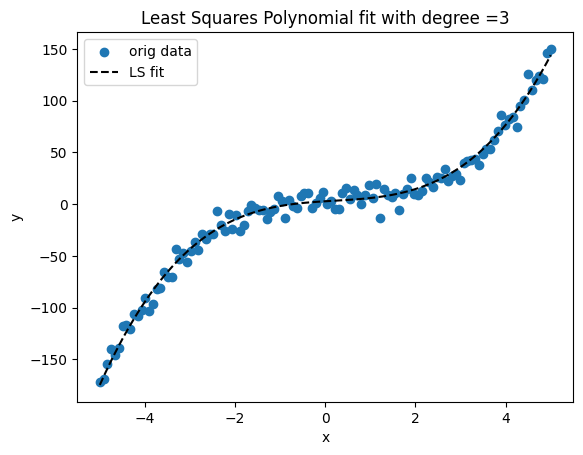

power: 5


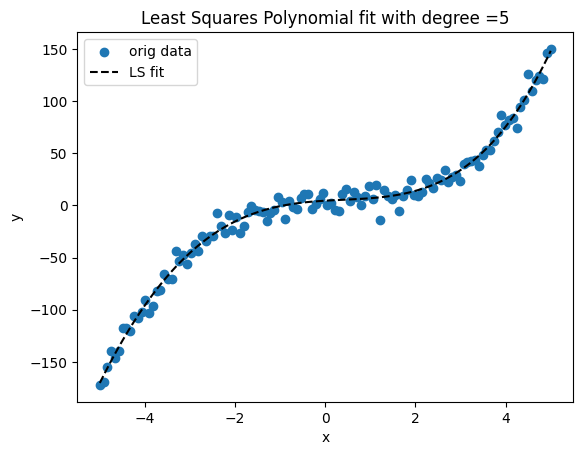

power: 15


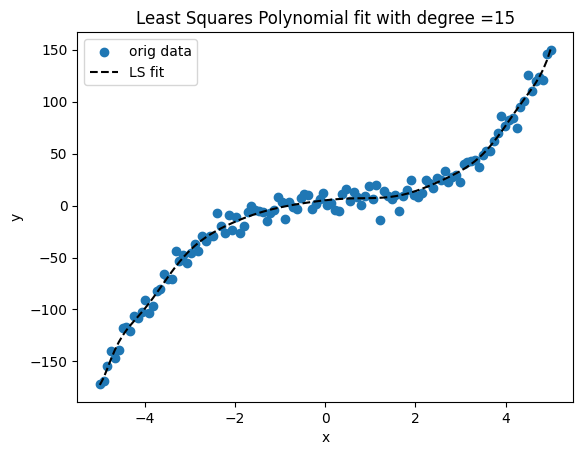

power: 75


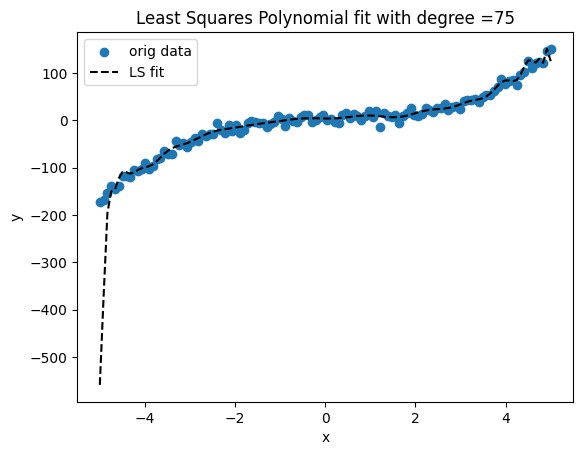

power: 120


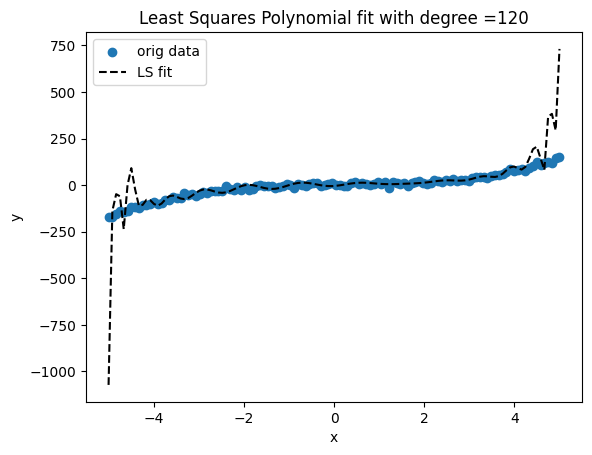

Test 2 -----------------------
Values of p: 200


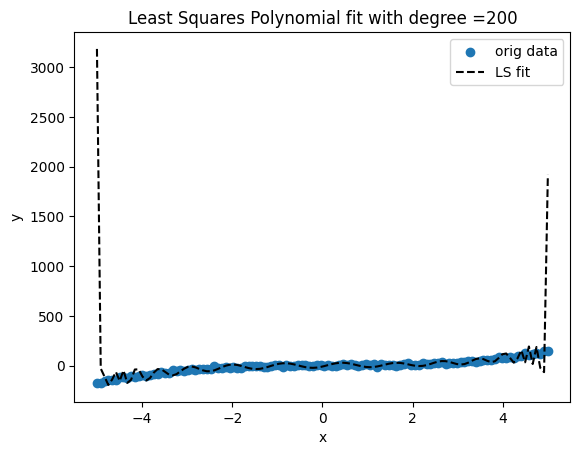

In [15]:
# examples

print('Test 1 -----------------------')
p_vals = [1, 2, 3, 5, 15, 75, 120]
print('Values of p:', p_vals)

for p_val in p_vals:
    print('power:', p_val)
    plot_least_squares(x, y, p_val)
    
print('Test 2 -----------------------')
p_val_large = 200
print('Values of p:', p_val_large)

plot_least_squares(x, y, p_val_large)


**Results:**
- **power < *P*** => the higher the power is, the better the LS fit line repeats original data up to some point. Then, a higher power adds heavier tails to the line
- **power > *P*** => model overfitting: 
        -- there are too many fitted points => 
        -- model is too sensitive to fluctuations + outliers => 
        -- stops finding general relationship between data, includes all the noise =>
        -- small change in regressor value *X* leads to significant change in predicted output *Y*

**Task 4:** Build OLS model
$$\hat{y}_i \approx \beta_1 educ_i + \beta_2 exper_i + \beta_3 tenure_i + \beta_3 tenure_i + \beta_4 female_i + \beta_5 married_i + \beta_6 nonwhite_i + \beta_7 numdep_i + \beta_8$$

\**Do we need tenure twice?*

In [16]:
# load data  \\  526 workers, 19 columns
df = woo.dataWoo('wage1')
# verify size
print(df.shape) # (526, 19) — the full dataset has 19 columns, we will use 7
print(df.head()) # shows the first 5 rows


(526, 24)
   wage  educ  exper  tenure  nonwhite  female  married  numdep  smsa  \
0  3.10    11      2       0         0       1        0       2     1   
1  3.24    12     22       2         0       1        1       3     1   
2  3.00    11      2       0         0       0        0       2     0   
3  6.00     8     44      28         0       0        1       0     1   
4  5.30    12      7       2         0       0        1       1     0   

   northcen  ...  trcommpu  trade  services  profserv  profocc  clerocc  \
0         0  ...         0      0         0         0        0        0   
1         0  ...         0      0         1         0        0        0   
2         0  ...         0      1         0         0        0        0   
3         0  ...         0      0         0         0        0        1   
4         0  ...         0      0         0         0        0        0   

   servocc     lwage  expersq  tenursq  
0        0  1.131402        4        0  
1        1  1.1755

In [17]:
# select needed cols
features = ['educ', 'exper', 'tenure', 'female','married', 'nonwhite', 'numdep']
X = df[features].values # shape: (526, 7)
y = df['wage'].values

# expand = +col w/ 1 = intercept
X_b = np.column_stack([X, np.ones(len(X))])  # shape: (526,8)
print(f'X_b shape: {X_b.shape}')   # should print (526, 8)

X_b shape: (526, 8)


**X_b** matrix has:
- 526 rows (for each observation) 
- 8 rows (for each feature/regressor + 1 column with '1' for intercept)

1 for column with intercept <=> $\beta_8*1$  \\  shows Y when other features=0

In [18]:
# estimate coefs

# Method A - Analytical formula
print('Analytical formula -----------------------')
from numpy.linalg import inv

beta_analytical = inv(X_b.T @ X_b) @ X_b.T @ y
beta_analytical = np.round(beta_analytical, 3)
print('Intercept: ', beta_analytical[-1])
print('Coefficients [β1 ... β7]:', beta_analytical[:7])

# Method B - Using scikit-learn
print('\nUsing scikit-learn -----------------------')
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print('Intercept: ', np.round(model.intercept_, 3))
print('Coefficients: ', np.round(model.coef_, 3))


Analytical formula -----------------------
Intercept:  -1.98
Coefficients [β1 ... β7]: [ 0.575  0.022  0.138 -1.759  0.46  -0.11   0.146]

Using scikit-learn -----------------------
Intercept:  -1.98
Coefficients:  [ 0.575  0.022  0.138 -1.759  0.46  -0.11   0.146]


**Results:**
- After rounding there teh coefficients are the same for both methods
- The coefficients may vary slightly as *sclearn* uses SVD or LAPACK to handle non-invertable matrices and decrease computational costs+memory usage 

**Task 5:** Explain the coefficients

**Intercept:** 
- $\beta_8 = 1.98$ => 
- an hourly wage, on average, is **USD 1.98** if there is no formal education, labor market experience, tenure, dependents in household and the person is an unmarried white male

**Education:** 
- $\beta_1 = 0.58 > 0$ => 
- an additional year of formal education, on average, increases the hourly wage by **USD 0.58**, ceteris paribus
- matches expectations

**Experience:** 
- $\beta_2 = 0.02 > 0$ => 
- an additional year of labor market experience, on average, increases the hourly wage by **USD 0.02**, ceteris paribus
- matches expectations

**Tenure:** 
- $\beta_3 = 0.14 > 0$ => 
- an additional year of tenure, on average, increases the hourly wage by **USD 0.14**, ceteris paribus
- matches expectations

**Female:** 
- $\beta_4 = -1.76 < 0$ => 
- for females, on average, the hourly wage is lower by **USD 1.76**, ceteris paribus
- matches expectations

**Married:** 
- $\beta_5 = 0.46 > 0$ => 
- for a married person, on average, the hourly wage is higher by **USD 0.46**, ceteris paribus
- matches expectations

**Non-white:** 
- $\beta_6 = -0.11 < 0$ => 
- for a non-white person, on average, the hourly wage is lower by **USD 0.11**, ceteris paribus
- matches expectations

**Dependents in Household:** 
- $\beta_7 = 0.15 > 0$ => 
- an additional dependent in household, on average, increases the hourly wage by **USD 0.15**, ceteris paribus
- had mixed expectations

**Human Capital Theory**: idea of humans increasing their productivity and efficiency through a greater focus on education and training
- $\beta_{educ} > \beta_{exper}$ => support HCT